# Test4

The test of our proposed algorithm.

## Implementation

copied from the networkx/drawing/layout.py

500


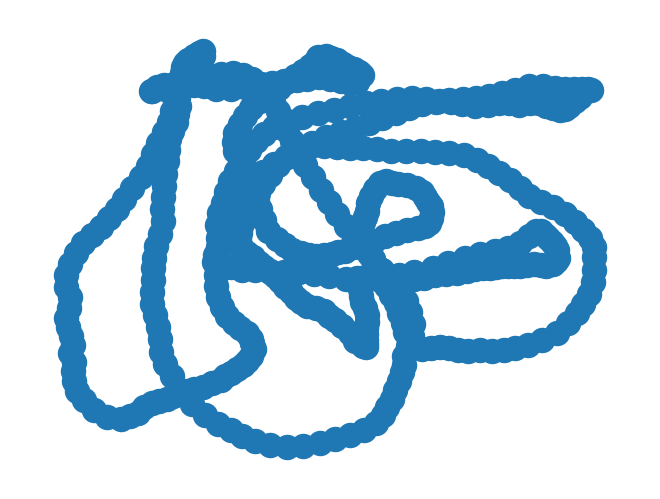

In [11]:
import networkx as nx

G= nx.cycle_graph(500)
print(len(G))
pos=nx.spring_layout(G,method="energy")
nx.draw(G,pos)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx


def make_fig(
    Gs: list,
    methods: list,
    file_name: str,
    legend_pos=1.0,
    rect_pos=0.96,
    rows=2,
    fontsize=30,
):
    assert len(Gs) % rows == 0

    n2 = len(Gs) // rows
    fig, axes = plt.subplots(
        rows * len(methods), n2, figsize=(3 * n2, 3 * rows * len(methods))
    )
    axes = axes.flatten()

    for i, (G, graph_name) in enumerate(Gs):
        for j, (draw_func, _, node_color, kwargs) in enumerate(methods):
            ax = axes[i % n2 + j * n2 + len(methods) * n2 * int(i / n2)]

            t0 = time.perf_counter()
            try:
                pos = draw_func(G, **kwargs)
            except ValueError as e:
                print(f"Error: {e}")
                # kamada_kawai_layout does not support negative edge weights
                pos = np.zeros((len(G), 2))
            t1 = time.perf_counter()
            print(f"{draw_func.__name__} took {t1 - t0:.2f}s")

            if type(pos) == np.ndarray:
                nodes = G.nodes()
                pos = dict(zip(nodes, pos))

            if j == 0:
                if graph_name.endswith("_graph"):
                    graph_name = graph_name[:-6]
                if graph_name == "dorogovtsev_goltsev_mendes":
                    graph_name = "DGM"
                ax.set_title(f"{graph_name}\n{t1 - t0:.2f}s", fontsize=20)
            else:
                ax.set_title(f"{t1 - t0:.2f}s", fontsize=20)

            # cmap = plt.get_cmap("jet")
            # n = G.number_of_nodes()
            # colorMap = np.array([cmap(i / (n - 1)) for i in range(n)])

            nx.draw(
                G,
                pos=pos,
                ax=ax,
                node_size=min(50, max(1, 5000 // len(G))),
                node_color=node_color,
                # node_color=colorMap,
            )
            ax.axis("on")

    handles = []
    for _, func_name, color, _ in methods:
        handles.append(mpatches.Patch(color=color, label=func_name))

    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=len(handles),
        bbox_to_anchor=(0.5, legend_pos),
        fontsize=fontsize,
    )

    plt.tight_layout(rect=(0.0, 0.0, 1.0, rect_pos))
    plt.savefig(file_name, dpi=300)
    plt.close()

This is the utility function for the test.

## Comparison

### NetworkX Graphs

In [ ]:
import networkx as nx
import scipy.sparse
import ssgetpy
import scipy

from networkx.drawing.nx_agraph import graphviz_layout


def shuffle_nodes(G):
    nodes = list(G.nodes)
    np.random.shuffle(nodes)
    mapping = {node: new_node for node, new_node in zip(G.nodes, nodes)}
    return nx.relabel_nodes(G, mapping)


def graph_generator(n: int):
    graph_functions = [
        (nx.complete_graph, [n]),
        (nx.path_graph, [n]),
        (nx.cycle_graph, [n]),
        (nx.circular_ladder_graph, [n // 2]),
        (nx.wheel_graph, [n]),
        (nx.star_graph, [n]),
        (nx.grid_2d_graph, [int(np.sqrt(n) + 1), int(np.sqrt(n) + 1)]),
        (nx.balanced_tree, [2, int(np.log2(n) + 1)]),
        (nx.binomial_tree, [int(np.log2(n) + 1)]),
        (nx.lollipop_graph, [4 * n // 5, n // 5]),
        (nx.barbell_graph, [2 * n // 5, n // 5]),
        (nx.ladder_graph, [n // 2]),
        (nx.dorogovtsev_goltsev_mendes_graph, [int(np.log(2 * n) / np.log(3) + 1)]),
        (nx.complete_bipartite_graph, [n // 2, n // 2]),
        (nx.barabasi_albert_graph, [n, 2]),
        (nx.powerlaw_cluster_graph, [n, 2, 0.5]),
        (nx.watts_strogatz_graph, [n, 2, 0.5]),
        (nx.random_regular_graph, [3, n]),
        (nx.bipartite.random_graph, [n // 2, n // 2, 0.5]),
        (nx.gnp_random_graph, [n, 0.5]),
        (nx.trivial_graph, []),
    ]
    return [
        (shuffle_nodes(func(*args)), func.__name__) for func, args in graph_functions
    ]


def make_methods(iterations: int):
    return [
        (
            nx.spring_layout,
            "old version (force)",
            "tab:blue",
            {"iterations": iterations, "method": "force", "seed": 0},
        ),
        (
            nx.spring_layout,
            "new version (energy)",
            "tab:orange",
            {"iterations": iterations, "method": "energy", "seed": 0},
        ),
        (
            graphviz_layout,
            "sfdp",
            "tab:green",
            {"prog": "sfdp", "args": f"-Gmaxiter={iterations}"},
        ),
    ]


make_fig(graph_generator(50), make_methods(50), "sfdp1", 1.03, 0.88, 1)

/home/hari64boli64/University/networkx/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


spring_layout took 0.01s
spring_layout took 0.20s
graphviz_layout took 0.11s
spring_layout took 0.01s
spring_layout took 0.09s
graphviz_layout took 0.04s
spring_layout took 0.01s
spring_layout took 0.06s
graphviz_layout took 0.03s
spring_layout took 0.02s
spring_layout took 0.07s
graphviz_layout took 0.06s
spring_layout took 0.01s
spring_layout took 0.19s
graphviz_layout took 0.04s
spring_layout took 0.02s
spring_layout took 0.07s
graphviz_layout took 0.03s
spring_layout took 0.02s
spring_layout took 0.26s
graphviz_layout took 0.06s
spring_layout took 0.05s
spring_layout took 0.15s
graphviz_layout took 0.09s
spring_layout took 0.01s
spring_layout took 0.10s
graphviz_layout took 0.05s
spring_layout took 0.01s
spring_layout took 0.09s
graphviz_layout took 0.10s
spring_layout took 0.01s
spring_layout took 0.29s
graphviz_layout took 0.10s
spring_layout took 0.01s
spring_layout took 0.22s
graphviz_layout took 0.04s
spring_layout took 0.06s
spring_layout took 0.23s
graphviz_layout took 0.11s

In [4]:
def graph_generator2():
    Gs = []

    n = 3
    G1 = nx.grid_2d_graph(n, n)
    G2 = nx.cycle_graph(n * n)
    G = nx.disjoint_union(G1, G2)

    Gs.append((G.copy(), "union"))

    G = G.copy()
    v = G.number_of_nodes()
    G.add_edge(v, 0, weight=-1)
    G.add_edge(v, n**2, weight=-1)
    Gs.append((G.copy(), "negative"))

    G = nx.erdos_renyi_graph(500, 0)
    Gs.append((G, "no edges"))

    return Gs


make_fig(graph_generator2(), make_methods(300), "sfdp2", 1.00, 0.88, 1, 20)

spring_layout took 0.02s
spring_layout took 0.05s
graphviz_layout took 0.03s
spring_layout took 0.03s
spring_layout took 0.06s
graphviz_layout took 0.02s
spring_layout took 11.15s
spring_layout took 2.58s
graphviz_layout took 2.00s
